In [1]:
# 1. ALWAYS force the backend before anything else
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# 2. Force the correct Keras import explicitly
import tf_keras as keras 
import tensorflow as tf
import tensorflow_model_optimization as tfmot

# 3. Clear the session to ensure no "ghost" Keras 3 objects are lingering
tf.keras.backend.clear_session()

2026-03-09 20:46:42.995885: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)
import os

from scipy.io import arff
import pandas as pd

#os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

In [3]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import tf_keras as keras

print(f"TensorFlow version: {tf.__version__}")
print(f"TFMOT version: {tfmot.__version__}")
print(f"tf-keras version: {keras.__version__}")

TensorFlow version: 2.20.0
TFMOT version: 0.8.0
tf-keras version: 2.20.1


In [4]:
X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1

In [6]:
model = Sequential()
model.add(Dense(64, input_shape=(16,), name='fc1', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu1'))
model.add(Dense(32, name='fc2', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu2'))
model.add(Dense(32, name='fc3', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='relu', name='relu3'))
model.add(Dense(5, name='output', kernel_initializer='lecun_uniform', kernel_regularizer=l1(0.0001)))
model.add(Activation(activation='softmax', name='softmax'))

I0000 00:00:1773085632.591137  100193 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

batch_size = 1024
epochs = 10

# Calculate end_step based on your dataset size
num_samples = len(X_train_val) * 0.75 
steps_per_epoch = np.ceil(num_samples / batch_size).astype(np.int32)
end_step = steps_per_epoch * epochs

pruning_params = {
    'pruning_schedule': sparsity.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.50, # Target 50% sparsity
        begin_step=0,
        end_step=end_step
    )
}
#pruning_params = {"pruning_schedule": sparsity.ConstantSparsity(0.75, begin_step=2000, frequency=100)}
# this gives Test loss: 0.8439908623695374,  Test accuracy: 0.7198795080184937
model = tfmot.sparsity.keras.prune_low_magnitude(model, **pruning_params)

In [8]:
os.makedirs('model_pruned', exist_ok=True)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=1000, verbose=1),
    ModelCheckpoint(filepath='model_pruned/best_model.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.0000001, verbose=1),
    
    # Pruning-specific callbacks
    sparsity.UpdatePruningStep(), 
    sparsity.PruningSummaries(log_dir='model_pruned/logs')
]

adam = Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

model.fit(
    X_train_val, 
    y_train_val, 
    epochs=epochs, 
    batch_size=batch_size, 
    validation_split=0.25, 
    shuffle=True, 
    callbacks=callbacks
)

# Strip the wrappers to get the plain Keras model back
model = sparsity.strip_pruning(model)
model.save('model_pruned/KERAS_check_best_model.h5')

Epoch 1/10


2026-03-09 20:47:29.208960: I external/local_xla/xla/service/service.cc:163] XLA service 0x73c6da3ebb00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-09 20:47:29.209006: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-09 20:47:29.235926: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-09 20:47:29.278245: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1773085649.396007  100962 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


486/487 [============================>.] - ETA: 0s - loss: 1.3379 - accuracy: 0.4908
Epoch 1: val_loss improved from inf to 1.14014, saving model to model_pruned/best_model.weights.h5
487/487 [==============================] - 13s 18ms/step - loss: 1.3377 - accuracy: 0.4908 - val_loss: 1.1401 - val_accuracy: 0.6050 - lr: 1.0000e-04
Epoch 2/10
485/487 [============================>.] - ETA: 0s - loss: 1.0759 - accuracy: 0.6327
Epoch 2: val_loss improved from 1.14014 to 1.03001, saving model to model_pruned/best_model.weights.h5
487/487 [==============================] - 8s 16ms/step - loss: 1.0757 - accuracy: 0.6328 - val_loss: 1.0300 - val_accuracy: 0.6567 - lr: 1.0000e-04
Epoch 3/10
487/487 [==============================] - ETA: 0s - loss: 0.9924 - accuracy: 0.6754
Epoch 3: val_loss improved from 1.03001 to 0.96579, saving model to model_pruned/best_model.weights.h5
487/487 [==============================] - 8s 17ms/step - loss: 0.9924 - accuracy: 0.6754 - val_loss: 0.9658 - val_accu

/home/slopin/hls4ml_proj/venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


% of zeros = 0.5


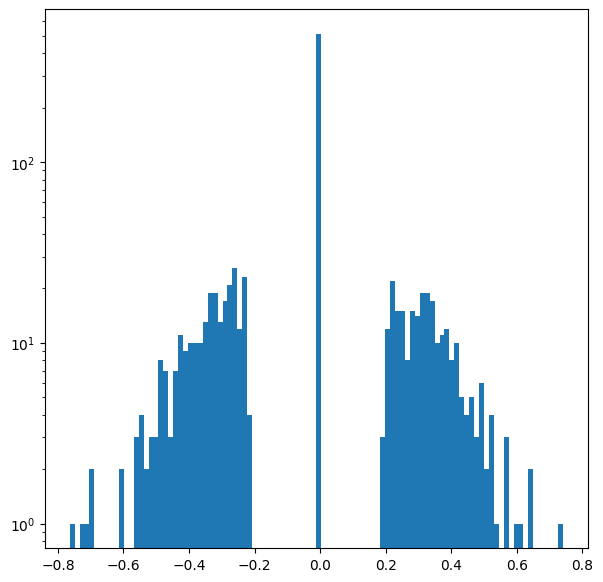

In [9]:
w = model.layers[0].weights[0].numpy()
h, b = np.histogram(w, bins=100)
plt.figure(figsize=(7, 7))
plt.bar(b[:-1], h, width=b[1] - b[0])
plt.semilogy()
print('% of zeros = {}'.format(np.sum(w == 0) / np.size(w)))

In [10]:
model.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.8162093162536621
Test accuracy: 0.7328252792358398
